# Laboratorio de regresión - 3

## Análisis exploratorio de datos y limpieza

|                |   |
:----------------|---|
| **Nombre**     | CECILIA QUIROZ HIDALGO  |
| **Fecha**      | 07/09/26  |
| **Expediente** | 757942  |

En los laboratorios y clases anteriores se ha visto que el modelo de regresión propuesto puede ser cualquier combinación lineal de factores independientes. Por lo tanto hay un número infinito de posibles modelos de regresión teóricos. ¿Cómo podemos deducir qué tipo de modelo podríamos necesitar?

Hay varios factores que pueden ayudarnos a elegir el tipo de modelo. Nosotros sabemos la teoría que respalda las regresiones, nos podríamos guiar de eso. Hacer una exploración de datos obtener gráficos también es una opción. También podemos hacer alguna prueba estadística que nos ayude a deducir el tipo de modelo que usaríamos. 

### EDA

El primer paso antes de poder proponer un modelo para predecir datos es entender el conjunto de datos con el que se está trabajando.
- ¿Cuántas muestras tiene?
- ¿Cuántos factores tiene?
- ¿Quién o qué hizo la recolección de las observaciones?
- ¿Cómo se hizo el muestreo?
- ¿En qué año se hicieron las observaciones?
- ¿En dónde se realizaron las observaciones?

El propósito de un análisis exploratorio de datos (EDA - Exploratory Data Analysis) es entender la naturaleza de los datos, comprender las relaciones existentes entre las variables para poder realizar hipótesis sobre cómo se relaciona la variable dependiente con las independientes.

#### Ejercicio 1: Dataset

Utiliza el dataset "Heart Prediction Dataset (Quantum)". Carga los datos y revisa qué factores contiene.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Heart Prediction Quantum Dataset.csv")

In [6]:
df.shape

(500, 6)

In [10]:
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,Hombre,105.00,191,107,1
1,58,Mujer,97.00,249,89,0
2,44,Mujer,93.00,190,82,1
3,72,Hombre,93.00,183,101,1
4,37,Mujer,145.00,166,103,1


Para cada factor, escribe qué significa cada variable.
- ¿Qué tipo de datos se observaron?
    - Numéricos
        - Enteros
        - Flotantes
    - Categóricos
        - Ordinales
        - No ordinales
- ¿Qué rango de valores sería esperado que contuviera cada factor? E.g. No esperaría encontrar un valor de Age de $-4$.

Investiga los valores esperados para variables que no entiendas como BloodPressure, Cholesterol, etc.

- Age: datos numéricos, enteros. No esperaría un valor negativo o muy alto (+200)
- Gender: datos categóricos, no ordinal. No esperaría celdas vacías o mal escritas. 
- BoolPressure: datos númericos, flotantes. No esperaría valores negativos, muy altos (+200) o muy bajos (-70).
- Cholesterol: datos numéricos, enteros. No esperaría valores negativos o muy altos (+500).
- HeartRate: datos numéricos, enteros. No esperaría valores negativos o valores muy altos (+500)
- HeartDisease: datos categóricos bool. No esperaría otro número que no sea 0 - 1.

A partir de lo investigado, describe el dataset con tus palabras.

Parece tener información de 500 pacientes, que tiene como objetivo saber si tienen una enfermedad cardíaca, y para esto se obtienen diferentes datos para de ahí predecir si tienen la enfermedad. 

#### Ejercicio 2: Factores

Ahora que se tiene un mejor entendimiento del dataset y de los valores que podría tener cada variable, es momento de revisar que las observaciones en el dataset estén dentro de ese rango esperado.

Crea un histograma para cada uno de los factores para ver el rango de los valores medidos y su distribución. 

In [11]:
import matplotlib.pyplot as plt

### Age

<Axes: >

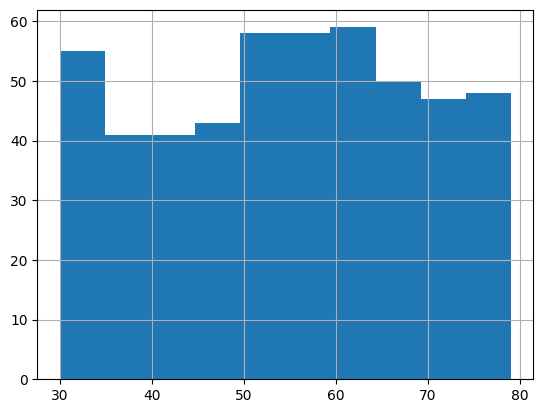

In [12]:
df["Age"].hist()

### Gender

<Axes: >

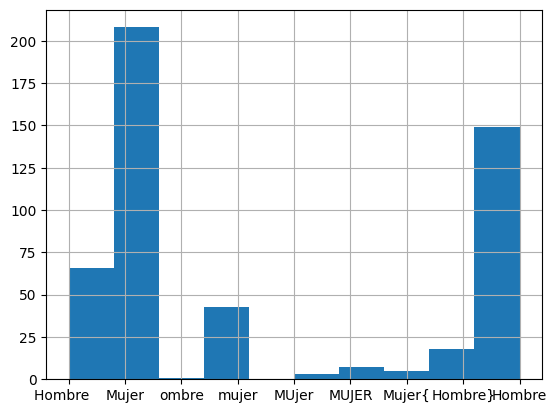

In [13]:
df["Gender"].hist()

### BloodPressure

<Axes: >

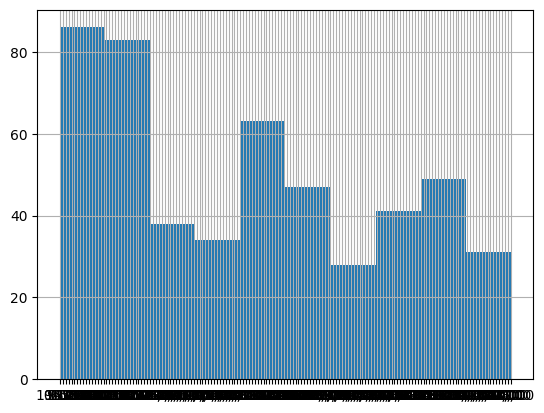

In [14]:
df["BloodPressure"].hist()

### Cholesterol

<Axes: >

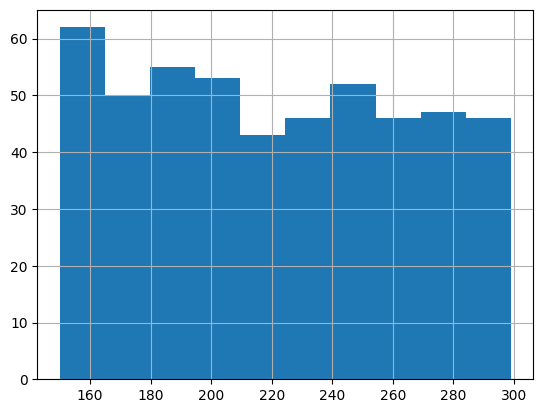

In [15]:
df["Cholesterol"].hist()

### HeartRate

<Axes: >

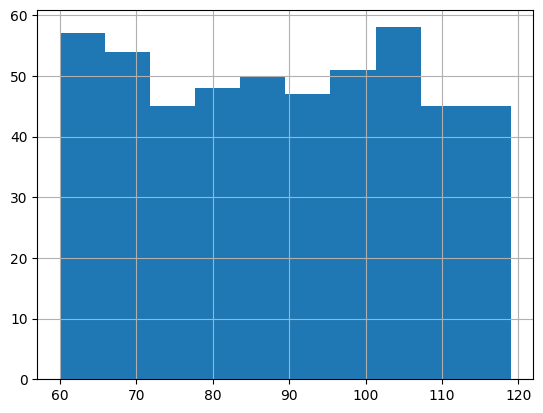

In [16]:
df["HeartRate"].hist()

### HeartDisease

<Axes: >

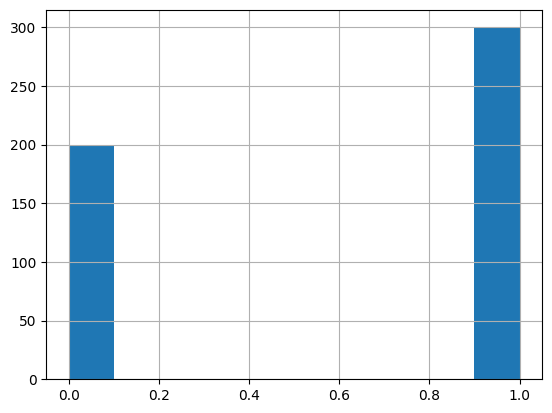

In [17]:
df["HeartDisease"].hist()

¿Parecen correctas estas distribuciones? ¿Qué valores atípicos encontraste? ¿Alguna inconsistencia? ¿Los problemas encontrados podrían ser casos reales?

- "Gender" tiene 9 diferentes variables, cuando debería tener solo dos, esto porque 7 están mal escritas o tienen algún símbolo extra, esto si es algo que podría pasar en casos reales, no tan extremo como escribir algo mal tantas veces, pero si que pase alguna vez. 
- "BloodPressure" se osberva que tiene un rango enorme de datos, cuando solo debería de estar dentro de un rango de 70 - 180 (según mi investigación), esto porque algunos tienen '.' para separar decimal y otros tienen ','.

#### Ejercicio 3: Limpieza

Es muy común que haya errores al registrar observaciones. Puede ser que personas diferentes hayan registrado datos con un estilo diferente, o que haya habido un error de dedo. También podrían haber registros duplicados, o datos faltantes.

Por ejemplo, la columna BloodPressure tiene dos estilos diferentes para el punto decimal (americano y europeo).

Utiliza `pandas.Series.str.replace` para cambiar el punto decimal de europeo a americano en la columna de BloodPressure. Después, cambia el tipo de dato de la columna a numérico. Dibuja el histograma de la variable corregida.

In [18]:
pd.Series.str.replace?

Signature:
pd.Series.str.replace(
    self,
    pat: 'str | re.Pattern',
    repl: 'str | Callable',
    n: 'int' = -1,
    case: 'bool | None' = None,
    flags: 'int' = 0,
    regex: 'bool' = False,
)
Docstring:
Replace each occurrence of pattern/regex in the Series/Index.

Equivalent to :meth:`str.replace` or :func:`re.sub`, depending on
the regex value.

Parameters
----------
pat : str or compiled regex
    String can be a character sequence or regular expression.
repl : str or callable
    Replacement string or a callable. The callable is passed the regex
    match object and must return a replacement string to be used.
    See :func:`re.sub`.
n : int, default -1 (all)
    Number of replacements to make from start.
case : bool, default None
    Determines if replace is case sensitive:

    - If True, case sensitive (the default if `pat` is a string)
    - Set to False for case insensitive
    - Cannot be set if `pat` is a compiled regex.

flags : int, default 0 (no flags)
    Rege

<Axes: >

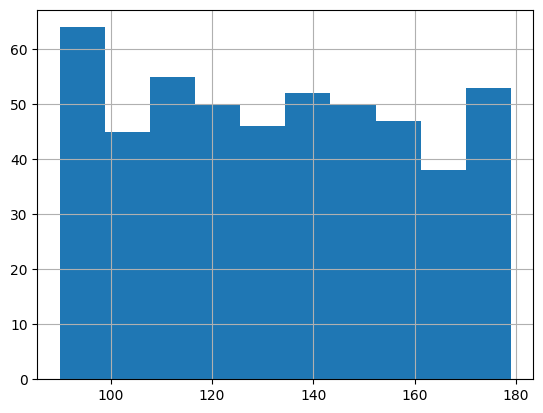

In [20]:
df["BloodPressure"] = df["BloodPressure"].str.replace(',', '.')
df["BloodPressure"] = df["BloodPressure"].astype(float)
df["BloodPressure"].hist()

La columna Gender tiene también errores de dedo y de estilo. Utiliza `pandas.Series.unique()` para encontrar las formas diferentes en las que se escribió "Hombre" y "Mujer".

In [22]:
df["Gender"].unique()

array(['Hombre   ', 'Mujer', 'ombre', 'mujer', 'MUjer', 'MUJER', 'Mujer{',
       'Hombre}', 'Hombre'], dtype=object)

La diferencia entre una mayúscula y minúscula para una computadora tiene que ver con la tabla ASCII. Para evitar esta variación utiliza `pandas.Series.str.lower()` para convertir todos las mayúsculas en minúsculas. Guarda el resultado en una variable auxiliar. Utiliza `unique()` una vez más para ver el resultado.

In [23]:
gender_lower = df['Gender'].str.lower()
gender_lower.unique()

array(['hombre   ', 'mujer', 'ombre', 'mujer{', 'hombre}', 'hombre'],
      dtype=object)

Observamos que hay errores como espacios en blanco o errores de dedo. Utiliza `pandas.Series.str.rstrip("xxx")` para limpiar los caracteres indeseados.

In [24]:
gender_clean = gender_lower.str.rstrip(" {}")
gender_clean.unique()

array(['hombre', 'mujer', 'ombre'], dtype=object)

Utiliza un filtro para corregir el typo de la 'h' faltante para la categoría "hombre".

In [25]:
gender_clean[gender_clean == 'ombre'] = 'hombre'
gender_clean.unique()

array(['hombre', 'mujer'], dtype=object)

Asigna "hombre"=1 y "mujer"=0 (Ojo con los tipos de dato. Considera que 0 es diferente a "0").

In [27]:
gender_clean.replace({'hombre': 1, 'mujer': 0})

C:\Users\ceciq\AppData\Local\Temp\ipykernel_22388\4164900164.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gender_clean.replace({'hombre': 1, 'mujer': 0})


0      1
1      0
2      0
3      1
4      0
      ..
495    0
496    0
497    1
498    0
499    0
Name: Gender, Length: 500, dtype: int64

Reescribe el resultado en el dataset original.

In [28]:
df['Gender'] = gender_clean.replace({'hombre': 1, 'mujer': 0})

C:\Users\ceciq\AppData\Local\Temp\ipykernel_22388\1793520420.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = gender_clean.replace({'hombre': 1, 'mujer': 0})


Para asegurarnos que no haya duplicados, utiliza `pd.DataFrame.drop_duplicates()`

In [29]:
df = df.drop_duplicates()

Para los valores faltantes se podría imputar, pero por ahora sólo elimínalos (si es que hay) con `pd.DataFrame.dropna()`

In [30]:
df = df.dropna()

#### Ejercicio 4: Verificación

Ahora que entendemos qué significan nuestras variables y que las limpiamos, vuelve a generar histogramas para cada variable.

<Axes: >

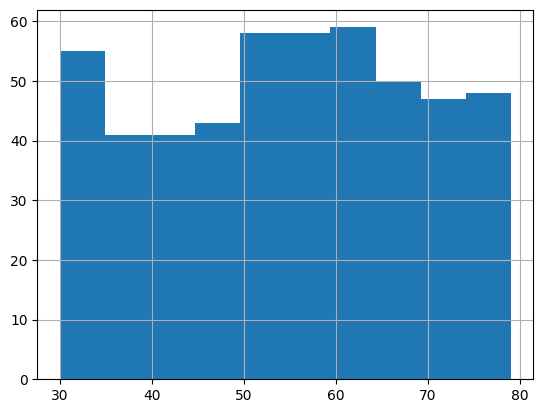

In [31]:
df["Age"].hist()

<Axes: >

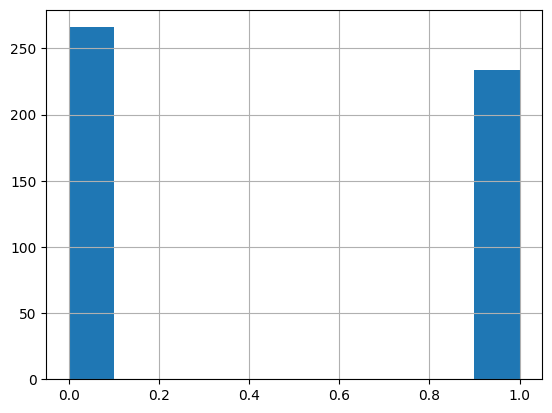

In [32]:
df["Gender"].hist()

<Axes: >

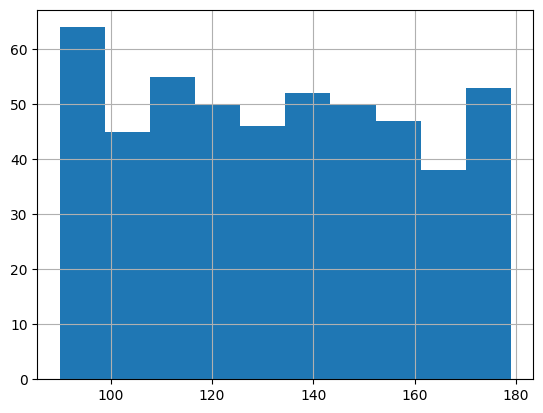

In [33]:
df["BloodPressure"].hist()

<Axes: >

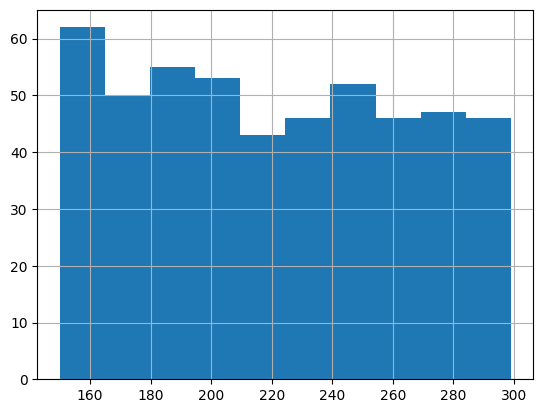

In [34]:
df["Cholesterol"].hist()

<Axes: >

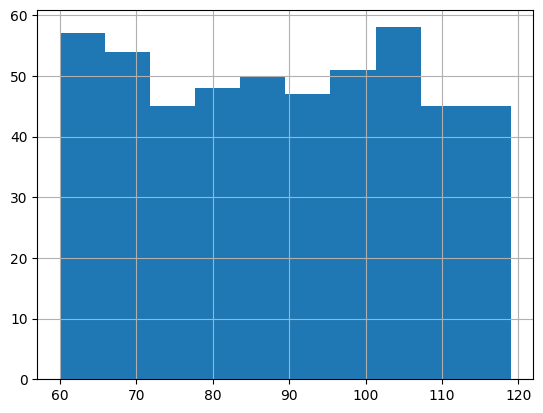

In [35]:
df["HeartRate"].hist()

<Axes: >

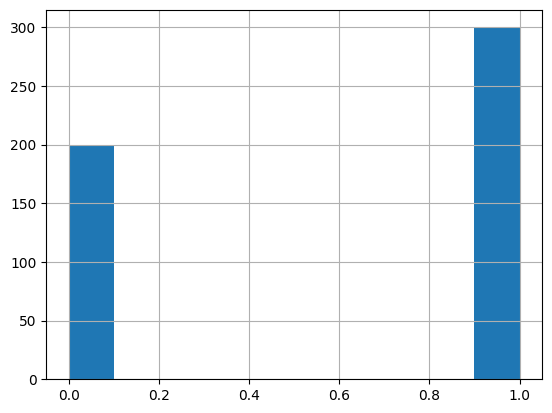

In [36]:
df["HeartDisease"].hist()

Encuentra la siguiente información para las variables numéricas:
- media
- mediana
- desviación estándar
- mínimo
- máximo

Genera un diagrama de caja para cada una. ¿Consideras que hay valores atípicos (outliers)?

In [37]:
df[["Age", "BloodPressure", "Cholesterol", "HeartRate"]].describe()

,Age,BloodPressure,Cholesterol,HeartRate
count,500.000000,500.000000,500.00000,500.000000
mean,54.864000,132.874000,221.50000,88.766000
std,14.315004,26.418516,43.86363,17.417289
min,30.000000,90.000000,150.00000,60.000000
25%,43.000000,111.000000,183.75000,73.000000
50%,55.000000,132.000000,221.00000,89.000000
75%,66.250000,155.000000,258.00000,104.000000
max,79.000000,179.000000,299.00000,119.000000


In [40]:
media = df[['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']].mean()
mediana = df[['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']].median()
std = df[['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']].std()
minimo = df[['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']].min()
maximo = df[['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']].max()
print(media)
print(mediana)
print(std)
print(minimo)
print(maximo)

Age               54.864
BloodPressure    132.874
Cholesterol      221.500
HeartRate         88.766
dtype: float64
Age               55.0
BloodPressure    132.0
Cholesterol      221.0
HeartRate         89.0
dtype: float64
Age              14.315004
BloodPressure    26.418516
Cholesterol      43.863630
HeartRate        17.417289
dtype: float64
Age               30.0
BloodPressure     90.0
Cholesterol      150.0
HeartRate         60.0
dtype: float64
Age               79.0
BloodPressure    179.0
Cholesterol      299.0
HeartRate        119.0
dtype: float64


<Axes: >

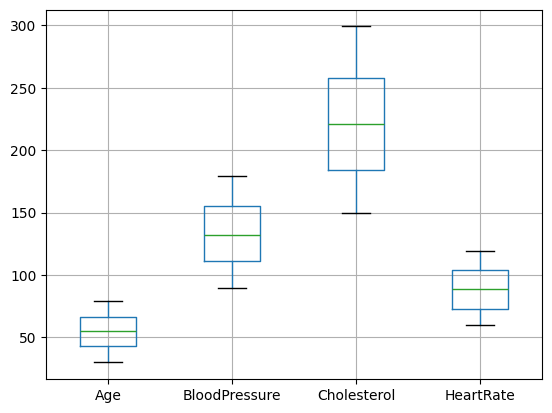

In [42]:
df[['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']].boxplot()

No hay valores atípicos. 

Encuentra la siguiente información para las variables categóricas:
- tabla de frecuencias
- valores únicos

In [45]:
df['Gender'].value_counts()

Gender
0    266
1    234
Name: count, dtype: int64

In [46]:
df['Gender'].unique()

array([1, 0])

In [47]:
df['HeartDisease'].value_counts()

HeartDisease
1    300
0    200
Name: count, dtype: int64

In [48]:
df['HeartDisease'].unique()

array([1, 0])

## Referencia

Dataset original tomado de: https://www.kaggle.com/datasets/shantanugarg274/heart-prediction-dataset-quantum